In [1]:
import jax
import jax.numpy as jnp
import inspeqtor as sq
from functools import partial
from alive_progress import alive_bar
import scienceplots as scienceplots
import matplotlib.pyplot as plt
from shared import get_predefined_data_model_m1, bound, train_model, colors
import polars as pl
from pathlib import Path
import seaborn as sns
import statistics
import time

plt.style.use("science")
sq.experimental.utils.enable_jax_x64()

In [2]:
import numpy as np


def format_value(val, scientific_threshold: float, precision: str):
    """Format a single value."""
    # String or header
    if isinstance(val, str):
        return val

    # Integer
    if isinstance(val, (int, np.integer, jnp.integer)):
        return str(val)

    # Float - check if scientific notation needed
    if isinstance(val, (float, np.floating, jnp.floating)):
        if abs(val) < scientific_threshold and val != 0:
            # Scientific notation
            formatted = f"{val:.{precision}e}"
            mantissa, exponent = formatted.split("e")
            exponent = int(exponent)
            return f"${mantissa} \\times 10^{{{exponent}}}$"
        else:
            # Regular decimal
            return f"{val:.{precision}f}"

    return str(val)


def dict_to_prb_table_with_units(
    nested_dict, caption="Parameters", label="tab:parameters"
):
    latex = r"\begin{table}[htbp]" + "\n"
    latex += r"\begin{ruledtabular}" + "\n"
    latex += r"\begin{tabular}{lrc}" + "\n"
    latex += r"Parameter & Value & Unit \\" + "\n"
    latex += r"\hline" + "\n"

    for i, (section, params) in enumerate(nested_dict.items()):
        latex += r"\multicolumn{3}{c}{\textbf{" + str(section) + r"}} \\" + "\n"
        latex += r"\hline" + "\n"

        for key, value_unit in params.items():
            if isinstance(value_unit, (tuple, list)):
                value, unit = value_unit
                latex += f"{key} & {value} & {unit} \\\\" + "\n"
            else:
                value_unit = format_value(
                    value_unit, scientific_threshold=1e-4, precision="7"
                )
                latex += f"{key} & {value_unit} & --- \\\\" + "\n"

        if i < len(nested_dict) - 1:
            latex += r"\hline" + "\n"

    latex += r"\end{tabular}" + "\n"
    latex += r"\end{ruledtabular}" + "\n"
    latex += r"\caption{" + caption + "}" + "\n"
    latex += r"\label{" + label + "}" + "\n"
    latex += r"\end{table}" + "\n"

    return latex


def gen_data(key: jnp.ndarray, shot: int, sample_size: int, trotter_step: int, detune: float):
    data_model = get_predefined_data_model_m1(detune)
    assert data_model.whitebox

    exp_data, *_ = sq.predefined.generate_single_qubit_experimental_data(
        key,
        data_model.total_hamiltonian,
        sample_size=sample_size,
        shots=shot,
        qubit_inforamtion=data_model.qubit_information,
        control_sequence=data_model.control_sequence,
        method=sq.experimental.predefined.WhiteboxStrategy.TROTTER,
        trotter_steps=trotter_step,
    )

    loaded_data = sq.utils.prepare_data(
        exp_data, data_model.control_sequence, data_model.whitebox
    )

    test_data = sq.optimize.DataBundled(
        control_params=sq.experimental.predefined.drag_feature_map(
            loaded_data.control_parameters
        ),
        unitaries=loaded_data.unitaries,
        observables=loaded_data.observed_values,
    )

    return test_data

## Define config

In [3]:
model_path = Path("./model/0001")
data_path = Path("./data/0001")
SHOTS = 1000
sample_size = 1000
validation_raito = 0.1
test_size = 1000
TROTTER_STEPS = 10_000
NUM_EPOCH = 5000
DETUNE = 0.0005
qubit_frequency = 5
control_step = 1000
qubit_detune = qubit_frequency * (1 + DETUNE)

In [4]:
# Example usage
data = {
    "Device (Hidden)": {"Frequency": (qubit_frequency, "GHz"), "Drive strength": (0.1, "GHz")},
    "Device (Spec)": {
        "Frequency": (qubit_detune, "GHz"),
        "Detune": (jnp.round(qubit_detune - qubit_frequency, 5).item(), "MHz"),
    },
    "Characterization": {
        "Shot": SHOTS,
        "Sample size": sample_size,
        "Training sample size": int(sample_size * (1 - validation_raito)),
        "Validation sample size": int(sample_size * validation_raito),
        "Epoch": NUM_EPOCH,
        "Optimizer warm-up step": int(0.1 * 0.8 * NUM_EPOCH),
        "Optimizer decay step": int(0.8 * NUM_EPOCH),
        "Model parameters": None, # 525, # TODO filled
        "Wall Clock": None, # (17.6, "s"), # TODO filled
        "Early stop epoch": None, # 1267, # TODO filled
        "Train loss (last epoch)":  None, # train_loss, # TODO filled
        "Val loss (last epoch)":  None, # val_loss, # TODO filled
        "Test loss (last epoch)":  None, # expected_loss, # TODO filled
    },
    "Calibration": {
        "Optimization Step": control_step,
        "Optimizer warm-up step": int(0.1 * control_step),
        "Optimizer decay step": int(0.8 * control_step),
        "Wall Clock": None, # (2 * 60 + 39, "s"), # TODO filled
    },
    "Benchmark (Exact)": {
        "Device":  None, # real_agf, # TODO filled
        "Model":  None, # predicted_agf, # TODO filled
        "Absolute Error":  None, # jnp.abs(real_agf - predicted_agf).item(), # TODO filled
    },
    "Benchmark (Finite-shot)": {
        "Device":  None, # finite_shot_device, # TODO filled
        "Model":  None, # finite_shot_model, # TODO filled
        "Absolute Error":  None, # jnp.abs(finite_shot_model - finite_shot_device).item(), # TODO filled
    },
}

In [7]:
data_model = get_predefined_data_model_m1(DETUNE)
assert data_model.whitebox

quantum_device = partial(
    sq.experimental.utils.shot_quantum_device,
    solver=data_model.solver,
    SHOTS=SHOTS,
    expectation_value_receipt=sq.constant.default_expectation_values_order,
)

data_model.quantum_device = quantum_device

key = jax.random.key(0)
exp_data, *_ = sq.predefined.generate_single_qubit_experimental_data(
    key,
    data_model.total_hamiltonian,
    sample_size=sample_size,
    shots=SHOTS,
    qubit_inforamtion=data_model.qubit_information,
    control_sequence=data_model.control_sequence,
    # method=sq.experimental.predefined.WhiteboxStrategy.TROTTER,
    method=sq.experimental.predefined.WhiteboxStrategy.ODE,
    # trotter_steps=TROTTER_STEPS,
)

sq.predefined.save_data_to_path(
    data_path,
    experiment_data=exp_data,
    control_sequence=data_model.control_sequence,
)


/Users/porametpathumsoot/University/PhD/Projects/espresso/inspeqtor-dev/.venv/lib/python3.13/site-packages/equinox/_jit.py:55: UserWarning: Complex dtype support in Diffrax is a work in progress and may not yet produce correct results. Consider splitting your computation into real and imaginary parts instead.
  out = fun(*args, **kwargs)


In [7]:
loaded_data = sq.predefined.load_data_from_path(
    data_path,
    sq.experimental.predefined.HamiltonianSpec(
        method=sq.experimental.predefined.WhiteboxStrategy.TROTTER,
        hamiltonian_enum=sq.experimental.predefined.HamiltonianEnum.rotating_transmon_hamiltonian,
        trotter_steps=TROTTER_STEPS,
    ),
)

SHOTS = loaded_data.experiment_data.config.shots

In [8]:
# Here, we just bundling things up for convinience uses.
key = jax.random.key(0)

key, random_split_key, training_key = jax.random.split(key, 3)
(
    train_control_parameters,
    train_unitaries,
    train_expectation_values,
    test_control_paramaeters,
    test_unitaries,
    test_expectation_values,
) = sq.experimental.utils.random_split(
    random_split_key,
    int(loaded_data.control_parameters.shape[0] * validation_raito),  # Test size
    loaded_data.control_parameters,
    loaded_data.unitaries,
    loaded_data.observed_values,
)

train_data = sq.optimize.DataBundled(
    control_params=sq.experimental.predefined.drag_feature_map(
        train_control_parameters
    ),
    unitaries=train_unitaries,
    observables=train_expectation_values,
)

val_data = sq.optimize.DataBundled(
    control_params=sq.experimental.predefined.drag_feature_map(
        test_control_paramaeters
    ),
    unitaries=test_unitaries,
    observables=test_expectation_values,
)

## Training with early stop

In [9]:
def early_stop(x, y, hist):
    expected_loss = hist[-1].loss

    if bound(expected_loss, shots=SHOTS) < 0.0005:
        return True

    return False

In [10]:
optimizer = sq.optimize.get_default_optimizer(8 * NUM_EPOCH)

model = sq.models.linen.WoModel(
    shared_layers=[10],
    pauli_layers=[10],
)

loss_fn = sq.models.linen.make_loss_fn(
    adapter_fn=sq.model.observable_to_expvals,
    model=model,
    calculate_metric_fn=sq.model.calculate_metric,
    loss_metric=sq.model.LossMetric.MSEE,
)

start_time = time.time()
with alive_bar(NUM_EPOCH, title="Training 🚀", force_tty=True) as bar:
    model_params, opt_state, histories = train_model(
        training_key,
        train_data=train_data,
        val_data=val_data,  # Here, we did not care about the validating dataset.
        test_data=val_data,
        model=model,
        optimizer=optimizer,
        loss_fn=loss_fn,
        callbacks=[lambda x, y, z: bar()],
        NUM_EPOCH=NUM_EPOCH,
        # early_stop_signal=early_stop
    )
stop_time = time.time()
data['Characterization']['Wall Clock'] = (jnp.round(stop_time - start_time).item(), "s")

Training 🚀 |████████████████████████████████████████| 5000/5000 [100%] in 58.4s


## Save model

In [11]:
model_state = sq.model.ModelData(
    params=model_params,
    config={
        "shared_layers": model.shared_layers,
        "pauli_layers": model.shared_layers,
    },
)

model_state.to_file(model_path / "model.json")

df = pl.DataFrame(sq.experimental.optimize.clean_history_entries(histories))
df.write_csv(model_path / "history.csv")
df

AE[F],MSE[E],WAE[E],loop,loss,step
f64,f64,f64,str,f64,i64
0.492516,0.329707,5.918653,"""train""",0.329707,0
0.49169,0.329449,5.908882,"""train""",0.329449,1
0.491279,0.328964,5.902893,"""train""",0.328964,2
0.492439,0.330435,5.918822,"""train""",0.330435,3
0.492102,0.329871,5.912571,"""train""",0.329871,4
…,…,…,…,…,…
0.002161,0.000663,0.094545,"""train""",0.000663,44997
0.002172,0.000699,0.09043,"""train""",0.000699,44998
0.002417,0.000733,0.105719,"""train""",0.000733,44999


## Benchmark with testing dataset

In [12]:
testing_dataset = gen_data(jax.random.key(0), SHOTS, test_size, TROTTER_STEPS, DETUNE)

In [13]:
model_state = sq.model.ModelData.from_file(model_path / "model.json")
num_model_parameters = sum(np.prod(x.shape) for x in jax.tree_util.tree_leaves(model_state.params))
data['Characterization']['Model parameters'] = int(num_model_parameters)

model = sq.models.linen.WoModel(**model_state.config)
predictive_fn = sq.models.linen.make_predictive_fn(
    sq.model.observable_to_expvals, model, model_state.params
)

predicted_expvals = predictive_fn(
    testing_dataset.control_params, testing_dataset.unitaries
)
se = jax.vmap(sq.models.mse)(predicted_expvals, testing_dataset.observables)

val_expvals = predictive_fn(val_data.control_params, val_data.unitaries)
val_se =  jax.vmap(sq.models.mse)(val_expvals, val_data.observables)

In [14]:
print(model.tabulate(key, loaded_data.control_parameters))


                                WoModel Summary                                 
┏━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ path    ┃ module  ┃ inputs           ┃ outputs           ┃ params            ┃
┡━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│         │ WoModel │ float64[1000,2]  │ X:                │                   │
│         │         │                  │ complex128[1000,… │                   │
│         │         │                  │ Y:                │                   │
│         │         │                  │ complex128[1000,… │                   │
│         │         │                  │ Z:                │                   │
│         │         │                  │ complex128[1000,… │                   │
├─────────┼─────────┼──────────────────┼───────────────────┼───────────────────┤
│ Dense_0 │ Dense   │ float64[1000,2]  │ float64[1000,10]  │ bias: float32[10] │
│         │         │      

Train loss:  0.0006793199165792009
Val loss:  0.000662927993938451
Test loss:  0.0006776809411610044


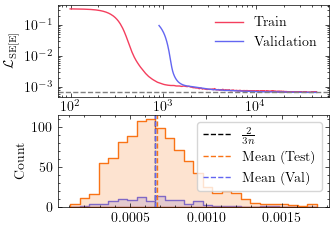

In [15]:
df = pl.read_csv(model_path / "history.csv")

default_figsize = jnp.array((3.5, 2.625))
fig, axes = plt.subplots(2, 1, figsize=default_figsize * jnp.array([1, 1]))
axes = sq.visualization.assert_list_of_axes(axes)

filtered_df = df.filter(pl.col("loop") == "train")
x = filtered_df["step"].to_numpy()
y = filtered_df["loss"].to_numpy()
train_loss = y[-9:].mean().item()
print("Train loss: ", train_loss)
sq.visualization.plot_loss_with_moving_average(
    x=x, y=y, ax=axes[0], annotate_at=[], label="Train", color=colors["red"], window=100
)

filtered_df = df.filter(pl.col("loop") == "val")
x = filtered_df["step"].to_numpy()
y = filtered_df["loss"].to_numpy()
sq.visualization.plot_loss_with_moving_average(
    x=x, y=y, ax=axes[0], annotate_at=[], label="Validation", color=colors["blue"], window=100
)

val_loss = y[-1].item()
print("Val loss: ", val_loss)

axes[0].axhline(
    y=2 / (3 * loaded_data.experiment_data.config.shots),
    color="gray",
    linestyle="dashed",
)

axes[0].set_ylabel(r"$\mathcal{L}_{\mathrm{SE[E]}}$")
axes[0].set_xlabel("Optimization step")

sq.visualization.set_fontsize(axes[0], 10)

axes[0].set_yscale("log")
axes[0].set_xscale("log")

# s = sns.histplot(np.array(se), element='step', color=colors['orange'], alpha=0.2, ax=axes[1])
s = sns.histplot({
    "Test": se,
    "Validation": val_se
}, element='step', palette={
    "Test": colors['orange'],
    "Validation": colors['blue']
}, alpha=0.2, ax=axes[1])

s.axvline(2/(3 * SHOTS), color='black', linestyle="dashed", label=r'$\frac{2}{3n}$')
expected_loss = statistics.mean(np.array(se))
print("Test loss: ", expected_loss)
s.axvline(expected_loss, color=colors['orange'], linestyle="dashed", label="Mean (Test)")
s.axvline(statistics.mean(np.array(val_se)), color=colors['blue'], linestyle="dashed", label="Mean (Val)")
axes[1].legend(frameon=True)

data['Characterization']["Train loss (last epoch)"] = train_loss
data['Characterization']["Val loss (last epoch)"] = val_loss
data['Characterization']["Test loss (last epoch)"] = expected_loss.item()


fig.savefig("./figure_4_loss.pdf")

## Calibration

In [16]:
model_state = sq.model.ModelData.from_file(model_path / "model.json")

model = sq.models.linen.WoModel(**model_state.config)
predictive_fn = sq.models.linen.make_predictive_fn(
    sq.model.observable_to_expvals, model, model_state.params
)


key, params_key = jax.random.split(key)
ravel_fn, unravel_fn = sq.control.ravel_unravel_fn(loaded_data.control_sequence)
sample_params = ravel_fn(loaded_data.control_sequence.sample_params(params_key))


def embed_predictive_model(control_parameters: jnp.ndarray):
    unitary_f = loaded_data.whitebox(control_parameters)[-1]
    return predictive_fn(
        sq.experimental.predefined.drag_feature_map(control_parameters), unitary_f
    )


calculate_agf_sx = sq.physics.direct_AGF_estimation_fn(sq.constant.SX)

@jax.jit
def average_gate_infidelity(params: jnp.ndarray):
    # Predict the expectation values
    predicted_expvals = embed_predictive_model(params)
    # Calculate the average gate fidelity with respected to SX gate.
    AGF = calculate_agf_sx(predicted_expvals)
    # return average gate infidelity squared and log the results.
    return (1 - AGF), {"AGF": AGF}

average_gate_infidelity(sample_params), embed_predictive_model(sample_params)

((Array(0.24670645, dtype=float64), {'AGF': Array(0.75329355, dtype=float64)}),
 Array([ 0.97649031, -0.97649031, -0.21339137,  0.21339137,  0.03050713,
        -0.03050713,  0.21653504, -0.21653504,  0.93850634, -0.93850634,
        -0.26892065,  0.26892065,  0.0248837 , -0.0248837 ,  0.27435036,
        -0.27435036,  0.96130779, -0.96130779], dtype=float64))

In [17]:
init_key = jax.random.key(73)
init_params = ravel_fn(loaded_data.control_sequence.sample_params(init_key))

lower, upper = loaded_data.control_sequence.get_bounds()

start_time = time.time()
with alive_bar(control_step, title="Optimizing 🚀", force_tty=True) as bar:
    optimized_params, aux = sq.optimize.minimize(
        init_params,
        average_gate_infidelity,
        sq.optimize.get_default_optimizer(int(control_step)),
        ravel_fn(lower),
        ravel_fn(upper),
        maxiter=control_step,
        callbacks=[lambda step, aux: bar()]
    )
stop_time = time.time()
predicted_agf = aux[-1]['AGF'].item()

data['Calibration']['Wall Clock'] = (jnp.round(stop_time - start_time).item(), "s")
data['Benchmark (Exact)']['Model'] = predicted_agf

aux[-1]

Optimizing 🚀 |                                        | ▁▃▅ 0/1000 [0%] in 0s (

Optimizing 🚀 |████████████████████████████████████████| 1000/1000 [100%] in 2:4


{'AGF': Array(0.99881863, dtype=float64),
 'params': Array([1.58411955, 4.70457729], dtype=float64)}

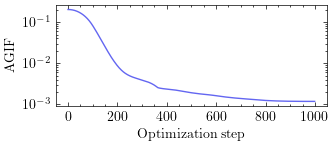

In [18]:
agifs = 1 - jnp.array([entry["AGF"].item() for entry in aux])
fig, ax = plt.subplots(figsize=default_figsize * jnp.array([1, 0.5]))
ax.plot(agifs, color=colors["blue"])

ax.set_xlabel("Optimization step")
ax.set_ylabel("AGIF")
ax.set_yscale("log")

fig.savefig("figure_5_optimization_loss.pdf")

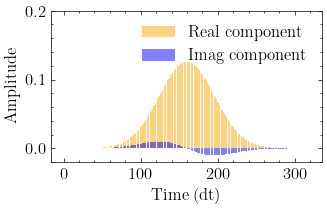

In [19]:
fig, ax = plt.subplots(figsize=default_figsize * jnp.array([1, 0.75]))

assert isinstance(optimized_params, jnp.ndarray)
waveform = sq.control.get_waveform(
    unravel_fn(optimized_params), loaded_data.control_sequence
)

sq.visualization.plot_control_envelope(
    waveform, loaded_data.control_sequence.controls['0'].t_eval, ax=ax
)

ax.set_ylim(-0.02, 0.2)
fig.savefig("figure_6_opitmized_envelope.pdf")

## Exact device

In [20]:
data_model = get_predefined_data_model_m1(DETUNE)

def quantum_device(params: jnp.ndarray):
    return sq.model.get_predict_expectation_value(
        {"X": sq.constant.X, "Y": sq.constant.Y, "Z": sq.constant.Z},
        data_model.solver(params)[-1],
        sq.constant.default_expectation_values_order,
    )

assert isinstance(optimized_params, jnp.ndarray)
real_expvals = quantum_device(optimized_params)

real_agf = calculate_agf_sx(real_expvals)
data['Benchmark (Exact)']['Device'] = real_agf.item()
data['Benchmark (Exact)']['Device']

0.9987182418624561

In [22]:
data['Benchmark (Exact)']['Absolute Error'] = jnp.abs(data['Benchmark (Exact)']['Device'] - data['Benchmark (Exact)']['Model']).item()

In [23]:
expected_loss = df.filter(pl.col("loop") == "test")[-1]["loss"].item()
real_agf - aux[-1]["AGF"], expected_loss, bound(expected_loss, SHOTS)

(Array(-0.00010039, dtype=float64),
 0.000662927993938451,
 Array(0., dtype=float64))

## Finite-shot AGF

In [24]:
assert isinstance(optimized_params, jnp.ndarray)

sample_size = 500
key = jax.random.key(0)
device_key, predict_key = jax.random.split(key)

quantum_device = partial(
    sq.experimental.utils.shot_quantum_device,
    solver=data_model.solver,
    SHOTS=SHOTS,
    expectation_value_receipt=sq.constant.default_expectation_values_order,
)

device_key, predict_key = jax.random.split(key)
device_expvals = quantum_device(
    device_key, jnp.broadcast_to(optimized_params, (sample_size, 2))
)
device_agfs = jax.vmap(calculate_agf_sx)(device_expvals)

predictive_model = sq.probabilistic.make_predictive_resampling_model(
    sq.models.linen.make_predictive_fn(
        sq.models.observable_to_expvals, model, model_state.params
    ),
    SHOTS,
)

unitary_f = loaded_data.whitebox(optimized_params)[-1]

predicted_expvals = jax.vmap(predictive_model, in_axes=(0, None, None))(
    jax.random.split(predict_key, sample_size),
    sq.experimental.predefined.drag_feature_map(optimized_params),
    unitary_f,
)

predicted_agfs = jax.vmap(calculate_agf_sx)(predicted_expvals)

data["Benchmark (Finite-shot)"]["Device"] = device_agfs.mean().item()
data["Benchmark (Finite-shot)"]["Model"] = predicted_agfs.mean().item()
data["Benchmark (Finite-shot)"]["Absolute Error"] = jnp.abs(
    predicted_agfs.mean().item() - device_agfs.mean().item()
).item()

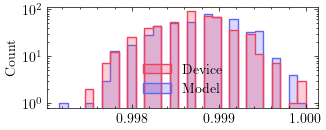

In [25]:
import seaborn as sns

fig, ax = plt.subplots(figsize=default_figsize * jnp.array([1, 0.5]))
sns.histplot(
    {"Device": device_agfs, "Model": predicted_agfs},
    palette={"Device": colors["red"], "Model": colors["blue"]},
    element="step",
    multiple='layer'
)

ax.set_yscale("log")

fig.savefig("figure_7_finite-shot-hist.pdf")

In [26]:
device_agfs.mean().item(), predicted_agfs.mean().item()

(0.9986933333333333, 0.9988023333333333)

## Drift device

In [33]:
drift_data_model = get_predefined_data_model_m1(detune=0.00075)

def drift_quantum_device(params: jnp.ndarray):
    return sq.model.get_predict_expectation_value(
        {"X": sq.constant.X, "Y": sq.constant.Y, "Z": sq.constant.Z},
        drift_data_model.solver(params)[-1],
        sq.constant.default_expectation_values_order,
    )

assert isinstance(optimized_params, jnp.ndarray)
drift_expvals = drift_quantum_device(optimized_params)

drift_agf = calculate_agf_sx(drift_expvals)
drift_agf.item()

0.9949571998226597

In [34]:
sq.experimental.data.save_pytree_to_json(data, model_path / "summary.json")

In [35]:
import json

with open(model_path / "summary.json", "r") as file:
    data_from_file = json.load(file)

print(
    dict_to_prb_table_with_units(
        data_from_file,
        caption="Experimental parameters and calibration settings. The train loss is an average over 9 batches of the last epoch.",
        label="tab:parameters",
    )
)


\begin{table}[htbp]
\begin{ruledtabular}
\begin{tabular}{lrc}
Parameter & Value & Unit \\
\hline
\multicolumn{3}{c}{\textbf{Benchmark (Exact)}} \\
\hline
Absolute Error & 0.0001004 & --- \\
Device & 0.9987182 & --- \\
Model & 0.9988186 & --- \\
\hline
\multicolumn{3}{c}{\textbf{Benchmark (Finite-shot)}} \\
\hline
Absolute Error & 0.0001090 & --- \\
Device & 0.9986933 & --- \\
Model & 0.9988023 & --- \\
\hline
\multicolumn{3}{c}{\textbf{Calibration}} \\
\hline
Optimization Step & 1000 & --- \\
Optimizer decay step & 800 & --- \\
Optimizer warm-up step & 100 & --- \\
Wall Clock & 164.0 & s \\
\hline
\multicolumn{3}{c}{\textbf{Characterization}} \\
\hline
Early stop epoch & None & --- \\
Epoch & 5000 & --- \\
Model parameters & 585 & --- \\
Optimizer decay step & 4000 & --- \\
Optimizer warm-up step & 400 & --- \\
Sample size & 1000 & --- \\
Shot & 1000 & --- \\
Test loss (last epoch) & 0.0006777 & --- \\
Train loss (last epoch) & 0.0006793 & --- \\
Training sample size & 900 & --- \\
Val